In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot configuration
sc.settings.set_figure_params(dpi=100, facecolor="white")

# Display versions
print("Scanpy version:", sc.__version__)
print("Pandas version:", pd.__version__)

Scanpy version: 1.11.5
Pandas version: 2.3.3


/tmp/ipykernel_514103/651593911.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [25]:
PROJECT_DIR = "./"
DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw", "01_10kHumanMelanomaGEMX")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
FILE = "10k_Human_DTC_Melanoma_3p_gemx_10k_Human_DTC_Melanoma_3p_gemx_count_sample_filtered_feature_bc_matrix.h5"

adata = sc.read_10x_h5(
    os.path.join(DATA_DIR, FILE)
)

adata.var_names_make_unique()

adata

/home/rangless/miniforge3/envs/bioinfo_portfolio/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/rangless/miniforge3/envs/bioinfo_portfolio/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10645 × 38606
    var: 'gene_ids', 'feature_types', 'genome'

In [26]:
# Check the headers of the dataset
adata.obs.head()

""
AAACCAAAGCTATCTC-1
AAACCAAAGGAGCTGA-1
AAACCAAAGGAGGTAT-1
AAACCAAAGTAAGCAA-1
AAACCAAAGTTAGTCG-1


In [27]:
# Check the dataset variables
adata.var.head()

,gene_ids,feature_types,genome
DDX11L2,ENSG00000290825,Gene Expression,GRCh38
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38


In [28]:
# Checing the dataset dimensions
adata.shape

(10645, 38606)

In [29]:

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [30]:
# Inspecting QC metrics
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCAAAGCTATCTC-1,5579,8.626944,29008.0,10.275361,23.079840,33.039162,43.198428,56.570601,605.0,6.406880,2.085632
AAACCAAAGGAGCTGA-1,5102,8.537584,28923.0,10.272427,24.468416,35.151955,46.979912,61.459738,619.0,6.429719,2.140165
AAACCAAAGGAGGTAT-1,3345,8.115521,13158.0,9.484861,23.043016,32.884937,44.680043,60.731114,426.0,6.056784,3.237574
AAACCAAAGTAAGCAA-1,2766,7.925519,11293.0,9.332026,33.852829,43.425131,54.325688,68.980785,234.0,5.459586,2.072080
AAACCAAAGTTAGTCG-1,3380,8.125927,17424.0,9.765661,30.922865,43.715565,56.307392,70.494720,485.0,6.186209,2.783517


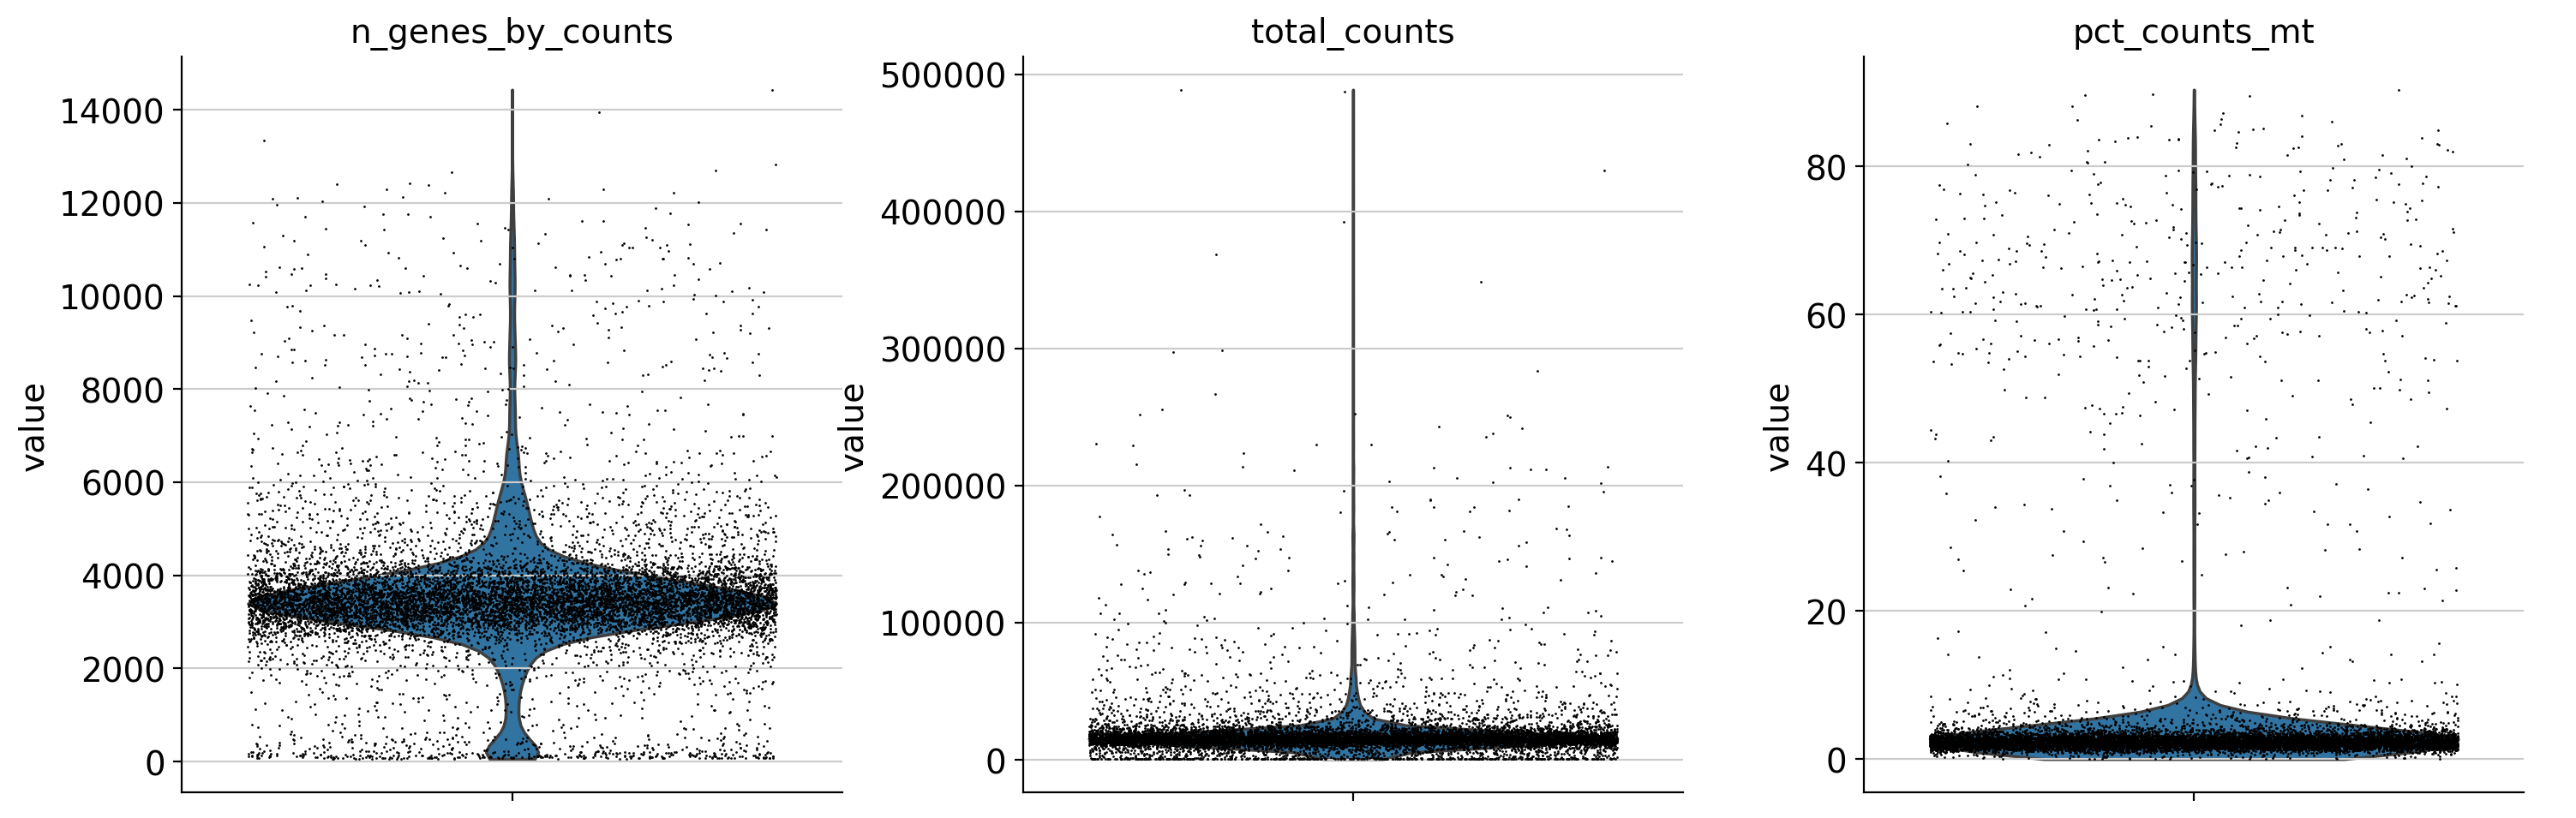

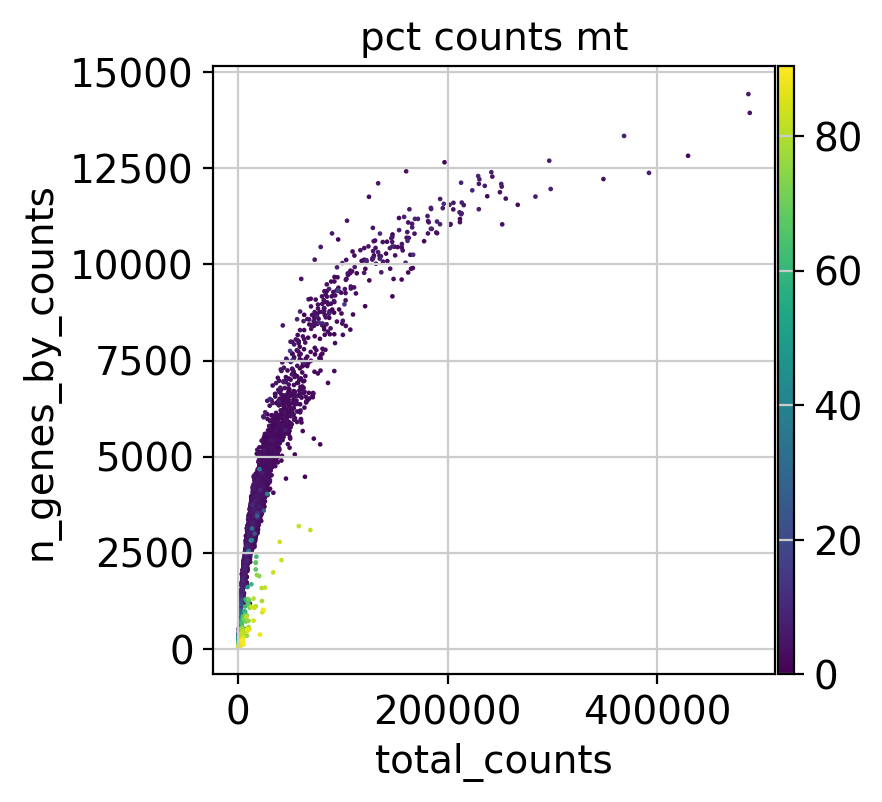

In [31]:
# Visualize initial QC distributions  
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

In [32]:
OUTPUT_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "processed",
    "melanoma_raw.h5ad"
)

adata.write(OUTPUT_PATH)